In [ ]:
# classification

In [1]:
# Load features + create result folders

import numpy as np
import pandas as pd
from pathlib import Path
from scipy import sparse

# Paths
FEATURE_DIR = Path("../data/features")
RESULTS_DIR = Path("../results")
FIG_DIR = RESULTS_DIR / "figures"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Load features
X_tfidf = sparse.load_npz(FEATURE_DIR / "tfidf.npz")
y = np.load(FEATURE_DIR / "labels.npy")
X_bert = np.load(FEATURE_DIR / "bert_embeddings.npy")

print("X_tfidf shape:", X_tfidf.shape)
print("X_bert shape:", X_bert.shape)
print("y shape:", y.shape)

# Class distribution
unique, counts = np.unique(y, return_counts=True)
class_dist = dict(zip(unique, counts))

print("\nClass distribution (counts):", class_dist)
print("Class distribution (proportions):", counts / counts.sum())

X_tfidf shape: (49998, 10000)
X_bert shape: (49998, 384)
y shape: (49998,)

Class distribution (counts): {np.int64(0): np.int64(13674), np.int64(1): np.int64(36324)}
Class distribution (proportions): [0.27349094 0.72650906]


In [2]:
#  One stratified split for fair comparison

from sklearn.model_selection import train_test_split

idx = np.arange(len(y))

train_idx, test_idx = train_test_split(
    idx,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train size:", len(train_idx))
print("Test size: ", len(test_idx))

# Class distribution in train/test
def dist(arr):
    u, c = np.unique(arr, return_counts=True)
    props = c / c.sum()
    return pd.DataFrame({"class": u, "count": c, "proportion": props})

print("\nTrain class distribution:")
print(dist(y[train_idx]))

print("\nTest class distribution:")
print(dist(y[test_idx]))

Train size: 39998
Test size:  10000

Train class distribution:
   class  count  proportion
0      0  10939    0.273489
1      1  29059    0.726511

Test class distribution:
   class  count  proportion
0      0   2735      0.2735
1      1   7265      0.7265


C:\Users\DELL\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


TF-IDF + Logistic Regression:
Accuracy=0.8529  Precision(macro)=0.8119  Recall(macro)=0.8470  F1(macro)=0.8254


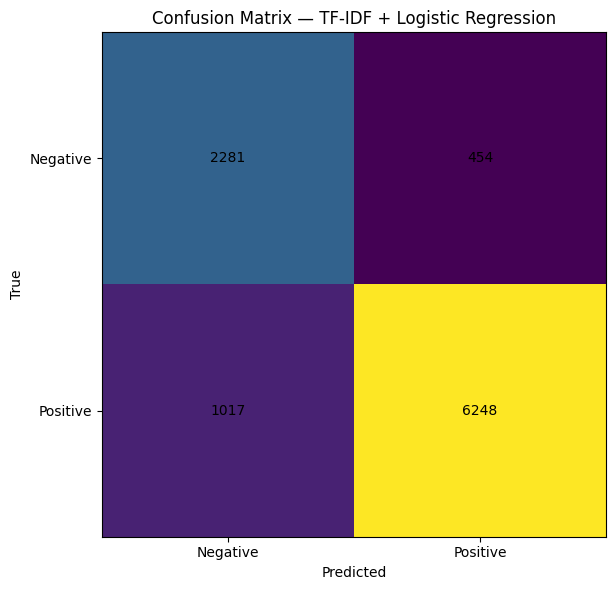

Saved: ..\results\figures\confusion_matrix_tfidf_logreg.png


In [3]:
# TF-IDF + Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt

X_train_tfidf = X_tfidf[train_idx]
X_test_tfidf  = X_tfidf[test_idx]
y_train = y[train_idx]
y_test  = y[test_idx]

logreg_tfidf = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    n_jobs=-1
)

logreg_tfidf.fit(X_train_tfidf, y_train)
y_pred = logreg_tfidf.predict(X_test_tfidf)

# Metrics (macro)
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average="macro", zero_division=0)
rec = recall_score(y_test, y_pred, average="macro", zero_division=0)
f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)

print("TF-IDF + Logistic Regression:")
print(f"Accuracy={acc:.4f}  Precision(macro)={prec:.4f}  Recall(macro)={rec:.4f}  F1(macro)={f1:.4f}")

# Confusion matrix plot
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 6))
plt.imshow(cm)
plt.title("Confusion Matrix — TF-IDF + Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks([0, 1], ["Negative", "Positive"])
plt.yticks([0, 1], ["Negative", "Positive"])

for (i, j), v in np.ndenumerate(cm):
    plt.text(j, i, str(v), ha="center", va="center")

plt.tight_layout()
out_path = FIG_DIR / "confusion_matrix_tfidf_logreg.png"
plt.savefig(out_path, dpi=300)
plt.show()

print("Saved:", out_path)

TF-IDF + Linear SVM:
Accuracy=0.8498  Precision(macro)=0.8082  Recall(macro)=0.8361  F1(macro)=0.8196


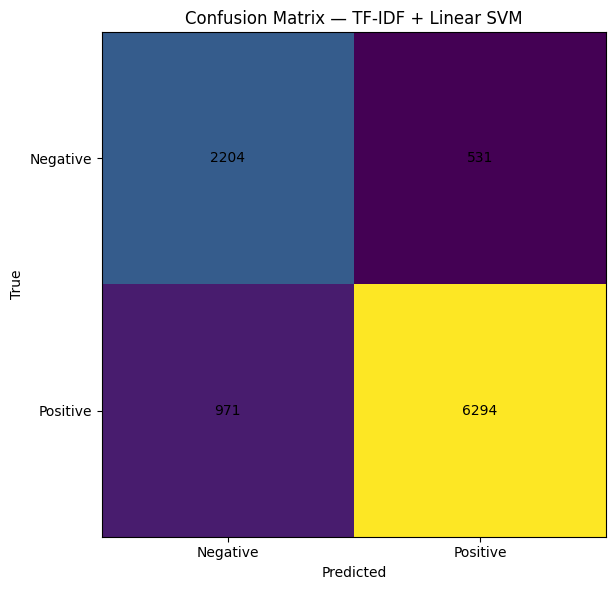

Saved: ..\results\figures\confusion_matrix_tfidf_linearsvm.png


In [4]:
# TF-IDF & Linear SVM

from sklearn.svm import LinearSVC

svm_tfidf = LinearSVC(
    class_weight="balanced",
    max_iter=5000
)

svm_tfidf.fit(X_train_tfidf, y_train)
y_pred_svm = svm_tfidf.predict(X_test_tfidf)

# Metrics
acc_svm = accuracy_score(y_test, y_pred_svm)
prec_svm = precision_score(y_test, y_pred_svm, average="macro", zero_division=0)
rec_svm = recall_score(y_test, y_pred_svm, average="macro", zero_division=0)
f1_svm = f1_score(y_test, y_pred_svm, average="macro", zero_division=0)

print("TF-IDF + Linear SVM:")
print(f"Accuracy={acc_svm:.4f}  Precision(macro)={prec_svm:.4f}  Recall(macro)={rec_svm:.4f}  F1(macro)={f1_svm:.4f}")

# Confusion matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(7, 6))
plt.imshow(cm_svm)
plt.title("Confusion Matrix — TF-IDF + Linear SVM")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks([0, 1], ["Negative", "Positive"])
plt.yticks([0, 1], ["Negative", "Positive"])

for (i, j), v in np.ndenumerate(cm_svm):
    plt.text(j, i, str(v), ha="center", va="center")

plt.tight_layout()
out_path_svm = FIG_DIR / "confusion_matrix_tfidf_linearsvm.png"
plt.savefig(out_path_svm, dpi=300)
plt.show()

print("Saved:", out_path_svm)

C:\Users\DELL\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


BERT + Logistic Regression:
Accuracy=0.7370  Precision(macro)=0.6978  Recall(macro)=0.7376  F1(macro)=0.7042


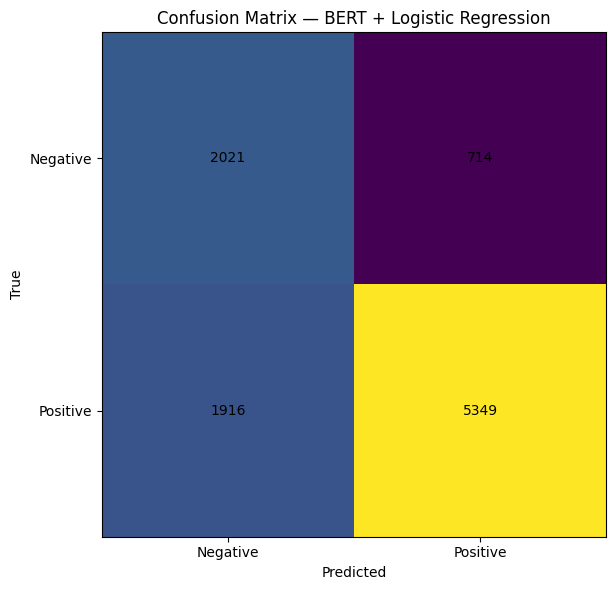

Saved: ..\results\figures\confusion_matrix_bert_logreg.png


In [5]:
#  BERT embeddings & Logistic Regression

X_train_bert = X_bert[train_idx]
X_test_bert  = X_bert[test_idx]

logreg_bert = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    n_jobs=-1
)

logreg_bert.fit(X_train_bert, y_train)
y_pred_bert = logreg_bert.predict(X_test_bert)

# Metrics
acc_bert = accuracy_score(y_test, y_pred_bert)
prec_bert = precision_score(y_test, y_pred_bert, average="macro", zero_division=0)
rec_bert = recall_score(y_test, y_pred_bert, average="macro", zero_division=0)
f1_bert = f1_score(y_test, y_pred_bert, average="macro", zero_division=0)

print("BERT + Logistic Regression:")
print(f"Accuracy={acc_bert:.4f}  Precision(macro)={prec_bert:.4f}  Recall(macro)={rec_bert:.4f}  F1(macro)={f1_bert:.4f}")

# Confusion matrix
cm_bert = confusion_matrix(y_test, y_pred_bert)

plt.figure(figsize=(7, 6))
plt.imshow(cm_bert)
plt.title("Confusion Matrix — BERT + Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks([0, 1], ["Negative", "Positive"])
plt.yticks([0, 1], ["Negative", "Positive"])

for (i, j), v in np.ndenumerate(cm_bert):
    plt.text(j, i, str(v), ha="center", va="center")

plt.tight_layout()
out_path_bert = FIG_DIR / "confusion_matrix_bert_logreg.png"
plt.savefig(out_path_bert, dpi=300)
plt.show()

print("Saved:", out_path_bert)

In [6]:
# Build comparison table + save CSV

results = pd.DataFrame([
    {
        "representation": "TF-IDF",
        "model": "LogisticRegression",
        "n_train": len(train_idx),
        "n_test": len(test_idx),
        "accuracy": acc,
        "precision_macro": prec,
        "recall_macro": rec,
        "f1_macro": f1,
        "notes": "sparse"
    },
    {
        "representation": "TF-IDF",
        "model": "LinearSVM",
        "n_train": len(train_idx),
        "n_test": len(test_idx),
        "accuracy": acc_svm,
        "precision_macro": prec_svm,
        "recall_macro": rec_svm,
        "f1_macro": f1_svm,
        "notes": "sparse"
    },
    {
        "representation": "BERT",
        "model": "LogisticRegression",
        "n_train": len(train_idx),
        "n_test": len(test_idx),
        "accuracy": acc_bert,
        "precision_macro": prec_bert,
        "recall_macro": rec_bert,
        "f1_macro": f1_bert,
        "notes": "dense (no fine-tuning)"
    }
])

results = results.sort_values("f1_macro", ascending=False)

csv_path = RESULTS_DIR / "classification_metrics.csv"
results.to_csv(csv_path, index=False)

print("===== FINAL MODEL COMPARISON =====")
print(results)
print("\nSaved metrics to:", csv_path)

===== FINAL MODEL COMPARISON =====
  representation               model  n_train  n_test  accuracy  \
0         TF-IDF  LogisticRegression    39998   10000    0.8529   
1         TF-IDF           LinearSVM    39998   10000    0.8498   
2           BERT  LogisticRegression    39998   10000    0.7370   

   precision_macro  recall_macro  f1_macro                   notes  
0         0.811945      0.847009  0.825427                  sparse  
1         0.808186      0.836098  0.819627                  sparse  
2         0.697786      0.737605  0.704243  dense (no fine-tuning)  

Saved metrics to: ..\results\classification_metrics.csv
